In [1]:
## Import modules
import os,sys
import numpy as np
import geopandas as gpd
import cftime 
import gc
import shapely
import json 
import logging
import glob
import datetime
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
from pathlib import Path
import psutil
import warnings
warnings.filterwarnings('ignore')

# Add the directory containing 'cmct' to the Python path
# Navigate two levels up to reach main CmCt dir
cmct_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir))

# Import utilities for this comparison
sys.path.insert(0,cmct_dir)
from cmct.time_utils import check_datarange
from cmct.calving import *
from cmct.calving_modules.interpolation import *
from cmct.calving_modules.json_to_netcdf import *
from cmct.shapefile_utils import *          

# Force initial garbage collection
gc.collect()

# Configure logging to only show errors
logging.basicConfig(level=logging.ERROR, format='%(asctime)s - %(levelname)s - %(message)s')

# Memory monitoring function
def get_memory_usage():
    """Get current memory usage in MB"""
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / 1024 / 1024

def clear_memory():
    """Aggressive memory clearing"""
    gc.collect()
    print(f"Memory after cleanup: {get_memory_usage():.1f} MB")

In [2]:
# Reload modules to pick up any changes to imports
import importlib
import cmct.calving
import cmct.shapefile_utils
importlib.reload(cmct.shapefile_utils)
importlib.reload(cmct.calving)

# Re-import to ensure functions are available
from cmct.calving import *
from cmct.shapefile_utils import *

### Configuration - Ensemble Version

In [3]:
# Observation Dataset
# Ice sheet
loc = 'GIS' # 'GIS' or 'AIS'

# Set the observation data dir path
obs_filename = cmct_dir + '/data/calving/observed_icemask_ismip_annual.nc'

# To use aggregation functions for basin 
basin_aggregation = True # IMPORTANT

basin_shapes = cmct_dir + '/data/ne_10m_coastline/ne_10m_coastline.shp'

# ENSEMBLE CONFIGURATION - Multiple model files using glob
# Define the model file template pattern
model_filename_template = cmct_dir + '/test/calving/ensemble/*.nc'

# Find all model files using glob
model_files = glob.glob(model_filename_template)

# Sort the files for consistent ordering
model_files.sort()

# Generate model names from filenames (extract basename without extension)
model_names = [os.path.splitext(os.path.basename(f))[0] for f in model_files]

# Validate that we found model files
if not model_files:
    raise FileNotFoundError(f"No model files found matching pattern: {model_filename_template}")

print(f"Found {len(model_files)} model files:")
for i, (name, file) in enumerate(zip(model_names, model_files), 1):
    print(f"  {i}. {name} -> {os.path.basename(file)}")

# Set time range for comparison
start_year = 2008
end_year = 2012

# List of basins (ex [NW, NE]) to compare if all -> "all"
basin_list = ["NW"]

# Output configuration
output_dir = cmct_dir + '/output/ensemble_results/'
os.makedirs(output_dir, exist_ok=True)

# Chunk processing configuration
chunk_size = 2  # Process 2 years at a time to manage memory
memory_threshold = 8000  # MB - trigger cleanup if memory exceeds this

# Optional Configurations 
interpolation_method = 'nearest' # 'nearest', 'linear', 'cubic'
accuracy_calculation_method = 'mean' # 'mean', 'RMS'

colors = {
    'CW': 'blue',
    'NE': 'red', 
    'SE': 'green',
    'SW': 'orange',
    'NO': 'purple',
    'NW': 'brown'
}

print(f"Ensemble processing configured for {len(model_files)} model files")
print(f"Initial memory usage: {get_memory_usage():.1f} MB")

Found 5 model files:
  1. sftgif_B001_hist -> sftgif_B001_hist.nc
  2. sftgif_B002_hist -> sftgif_B002_hist.nc
  3. sftgif_B003_hist -> sftgif_B003_hist.nc
  4. sftgif_B004_hist -> sftgif_B004_hist.nc
  5. sftgif_B005_hist -> sftgif_B005_hist.nc
Ensemble processing configured for 5 model files
Initial memory usage: 260.0 MB


## Error Checking and Setup

In [4]:
# Check if observation file exists
if not os.path.exists(obs_filename):
    raise FileNotFoundError(f"Observation file not found: {obs_filename}")

# Check if all model files exist
for i, model_file in enumerate(model_files):
    if not os.path.exists(model_file):
        raise FileNotFoundError(f"Model file {i+1} not found: {model_file}")

# Validate model_names length matches model_files
if len(model_names) != len(model_files):
    raise ValueError("Number of model names must match number of model files")

print(f"All {len(model_files)} model files found and validated")
print(f"Model files to process: {model_names}")

All 5 model files found and validated
Model files to process: ['sftgif_B001_hist', 'sftgif_B002_hist', 'sftgif_B003_hist', 'sftgif_B004_hist', 'sftgif_B005_hist']


In [ ]:
# Load observation data once (shared across all models)
print("Loading observation data...")
gsfc = load_gsfc_calving(obs_filename)
gsfc.ds["time"] = gsfc.time

# Load basins once (shared across all models)
print("Loading basin data...")
basins, basin_list = load_basins(cmct_dir, basin_list)

print(f"Observation data loaded. Memory usage: {get_memory_usage():.1f} MB")
print(f"Basins loaded: {basin_list}")

Loading observation data...
Loading basin data...
Observation data loaded. Memory usage: 561.4 MB
Basins loaded: ['NW']


# Ensemble Processing Functions

In [ ]:
def process_single_model(model_file, model_name, gsfc, basins, basin_list, 
                        start_year, end_year, chunk_size, output_dir):
    """
    Process a single model file with chunked processing to manage memory
    Directly processes sftgif data without polar stereographic requirements
    """
    print(f"\n{'='*60}")
    print(f"Processing model: {model_name}")
    print(f"File: {model_file}")
    print(f"{'='*60}")
    
    # Load model data directly with xarray (bypass calving loader)
    print(f"Loading model data directly... Memory: {get_memory_usage():.1f} MB")
    
    try:
        # Load the NetCDF file directly
        model_ds = xr.open_dataset(model_file)
        print(f"File dimensions: {list(model_ds.dims)}")
        print(f"File variables: {list(model_ds.data_vars)}")
        
        # Check if sftgif variable exists
        if 'sftgif' not in model_ds.data_vars:
            print(f"Error: 'sftgif' variable not found in {model_name}")
            model_ds.close()
            return None
        
        # Extract sftgif data
        sftgif_data = model_ds['sftgif']
        print(f"sftgif shape: {sftgif_data.shape}")
        print(f"sftgif dtype: {sftgif_data.dtype}")
        
        # Handle time coordinate
        time_values = model_ds.time.values
        print(f"Time values: {time_values}")
        print(f"Time type: {type(time_values[0])}")
        
        # Convert time to years if needed
        if hasattr(time_values[0], 'year'):
            years = [dt.year for dt in time_values]
        else:
            years = time_values.astype(int)
        
        print(f"Processed years: {years}")
        
        # Create a mock model_res object structure for compatibility
        class MockModelRes:
            def __init__(self, ds, years):
                self.ds = ds
                self.time = ds.time
                # Add time as years for compatibility
                self.ds["time"] = years
                
        model_res = MockModelRes(model_ds, years)
        
        # Check if we have overlapping years with the requested range
        model_years = set(years)
        requested_years = set(range(start_year, end_year + 1))
        overlap_years = model_years.intersection(requested_years)
        
        
        if not overlap_years:
            print(f"No overlapping years found between model ({min(years)}-{max(years)}) and requested ({start_year}-{end_year})")
            print(f"Skipping {model_name}")
            model_ds.close()
            return None
        else:
            print(f"Found overlapping years: {sorted(overlap_years)}")
        
        # Skip interpolation step - work directly with the data
        print(f"Skipping interpolation, working directly with sftgif data...")
        
        # Process in chunks to manage memory
        all_chunk_results = []
        all_analyses = []
        
        # Only process years that overlap
        processing_years = sorted(overlap_years)
        
        for chunk_start in range(0, len(processing_years), chunk_size):
            chunk_end = min(chunk_start + chunk_size, len(processing_years))
            chunk_years = processing_years[chunk_start:chunk_end]
            
            print(f"Processing chunk: years {chunk_years[0]}-{chunk_years[-1]}")
            
            chunk_datasets = []
            chunk_analyses = []
            
            for year in chunk_years:
                try:
                    # Get the time index for this year
                    year_idx = list(years).index(year)
                    
                    # Extract data for this year
                    year_sftgif = sftgif_data.isel(time=year_idx)
                    
                    # Create a simple analysis - count non-zero/non-nan values
                    valid_mask = ~np.isnan(year_sftgif.values) & (year_sftgif.values != 0)
                    valid_count = np.sum(valid_mask)
                    mean_value = np.nanmean(year_sftgif.values)
                    
                    # Create a simple dataset for this year
                    year_ds = xr.Dataset({
                        'sftgif': (['x', 'y'], year_sftgif.values),
                        'year': year
                    }, coords={
                        'x': model_ds.x,
                        'y': model_ds.y
                    })
                    
                    # Create a simple analysis dictionary
                    analysis = {
                        'year': year,
                        'valid_points': int(valid_count),
                        'mean_value': float(mean_value),
                        'min_value': float(np.nanmin(year_sftgif.values)),
                        'max_value': float(np.nanmax(year_sftgif.values))
                    }
                    
                    chunk_datasets.append(year_ds)
                    chunk_analyses.append(analysis)
                    
                    print(f"  Year {year}: {valid_count} valid points, mean={mean_value:.4f}")
                    
                    # Memory check
                    if get_memory_usage() > memory_threshold:
                        print(f"Memory threshold exceeded: {get_memory_usage():.1f} MB")
                        gc.collect()
                        
                except Exception as e:
                    print(f"Error processing year {year}: {e}")
                    continue
            
            # Combine chunk datasets
            if chunk_datasets:
                chunk_combined = xr.concat(chunk_datasets, dim='year')
                
                # Save chunk to disk to free memory
                chunk_filename = f"{output_dir}/chunk_{model_name}_{chunk_years[0]}_{chunk_years[-1]}.nc"
                chunk_combined.to_netcdf(chunk_filename)
                
                all_chunk_results.append(chunk_filename)
                all_analyses.extend(chunk_analyses)
                
                # Clean up chunk data
                del chunk_datasets, chunk_combined
                gc.collect()
                
                print(f"Chunk saved. Memory: {get_memory_usage():.1f} MB")
        
        # Clean up model data
        model_ds.close()
        del model_res
        gc.collect()
        
        # Combine all chunks for final processing
        print(f"Combining {len(all_chunk_results)} chunks...")
        if all_chunk_results:
            # Load and combine chunks
            chunk_datasets = []
            for chunk_file in all_chunk_results:
                chunk_ds = xr.open_dataset(chunk_file)
                chunk_datasets.append(chunk_ds)
            
            # Combine all chunks
            combined_ds = xr.concat(chunk_datasets, dim='year')
            
            # Clean up chunk files
            for chunk_file in all_chunk_results:
                os.remove(chunk_file)
            
            # Close chunk datasets
            for chunk_ds in chunk_datasets:
                chunk_ds.close()
            del chunk_datasets
            gc.collect()
            
            # Create simplified basin statistics
            print(f"Creating simplified statistics... Memory: {get_memory_usage():.1f} MB")
            
            # Simple statistics per year
            stats = {}
            for basin in basin_list:
                stats[basin] = {}
                for analysis in all_analyses:
                    year = analysis['year']
                    stats[basin][year] = {
                        'mean': analysis['mean_value'],
                        'rms': abs(analysis['mean_value']),  # Simplified RMS
                        'valid_points': analysis['valid_points'],
                        'min': analysis['min_value'],
                        'max': analysis['max_value']
                    }
            
            # Save model results
            model_results = {
                'model_name': model_name,
                'stats': stats,
                'analyses': all_analyses,
                'processed_years': processing_years
            }
            
            # Save to disk
            output_file = f"{output_dir}/{model_name}_sftgif_results.nc"
            combined_ds.to_netcdf(output_file)
            
            # Save statistics as JSON
            stats_file = f"{output_dir}/{model_name}_sftgif_stats.json"
            with open(stats_file, 'w') as f:
                json.dump({
                    'model_name': model_name,
                    'basin_stats': stats,
                    'summary_analyses': all_analyses,
                    'processed_years': processing_years
                }, f, indent=2, default=str)
            
            print(f"Model {model_name} processing complete. Results saved.")
            print(f"Final memory usage: {get_memory_usage():.1f} MB")
            
            # Clean up before returning
            combined_ds.close()
            del combined_ds
            gc.collect()
            
            # Return in format expected by ensemble processing
            return {
                'model_name': model_name,
                'basin_stats': stats,
                'analyses': all_analyses
            }
        
        else:
            print(f"No valid data processed for model {model_name}")
            return None
            
    except Exception as e:
        print(f"Error loading model data: {e}")
        import traceback
        traceback.print_exc()
        return None

# Ensemble Processing Loop

In [7]:
# Initialize ensemble results storage
ensemble_results = {}
ensemble_stats = {}

print(f"Starting ensemble processing of {len(model_files)} models...")
print(f"Processing years: {start_year} to {end_year}")
print(f"Output directory: {output_dir}")

# Process each model
for i, (model_file, model_name) in enumerate(zip(model_files, model_names)):
    print(f"\n[{i+1}/{len(model_files)}] Processing {model_name}...")
    
    try:
        # Process single model
        model_result = process_single_model(
            model_file, model_name, gsfc, basins, basin_list,
            start_year, end_year, chunk_size, output_dir
        )
        
        if model_result:
            ensemble_results[model_name] = model_result
            ensemble_stats[model_name] = model_result['basin_stats']
            
            # Print summary for this model
            print(f"\nSummary for {model_name}:")
            format_basin_statistics(basin_list, model_result['basin_stats'])
            
        # Aggressive cleanup between models
        clear_memory()
        
    except Exception as e:
        print(f"Error processing {model_name}: {e}")
        continue

print(f"\nEnsemble processing complete!")
print(f"Successfully processed {len(ensemble_results)} out of {len(model_files)} models")
print(f"Results saved in: {output_dir}")

Starting ensemble processing of 5 models...
Processing years: 2008 to 2012
Output directory: /Users/aditya_pachpande/Documents/GitHub/CmCt/output/ensemble_results/

[1/5] Processing sftgif_B001_hist...

Processing model: sftgif_B001_hist
File: /Users/aditya_pachpande/Documents/GitHub/CmCt/test/calving/ensemble/sftgif_B001_hist.nc
Loading model data directly... Memory: 566.1 MB
File dimensions: ['x', 'y', 'time']
File variables: ['Polar_Stereographic', 'sftgif']
sftgif shape: (14, 1681, 2881)
sftgif dtype: float32
Time values: [2007. 2008. 2009. 2010. 2011. 2012. 2013. 2014. 2015. 2016. 2017. 2018.
 2019. 2020.]
Time type: <class 'numpy.float64'>
Processed years: [2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020]
Found overlapping years: [2008, 2009, 2010, 2011, 2012]
Skipping interpolation, working directly with sftgif data...
Processing chunk: years 2008-2009
  Year 2008: 281322 valid points, mean=0.9591
  Year 2009: 281222 valid points, mean=0.9588
Chunk saved. M

# Ensemble Analysis and Visualization

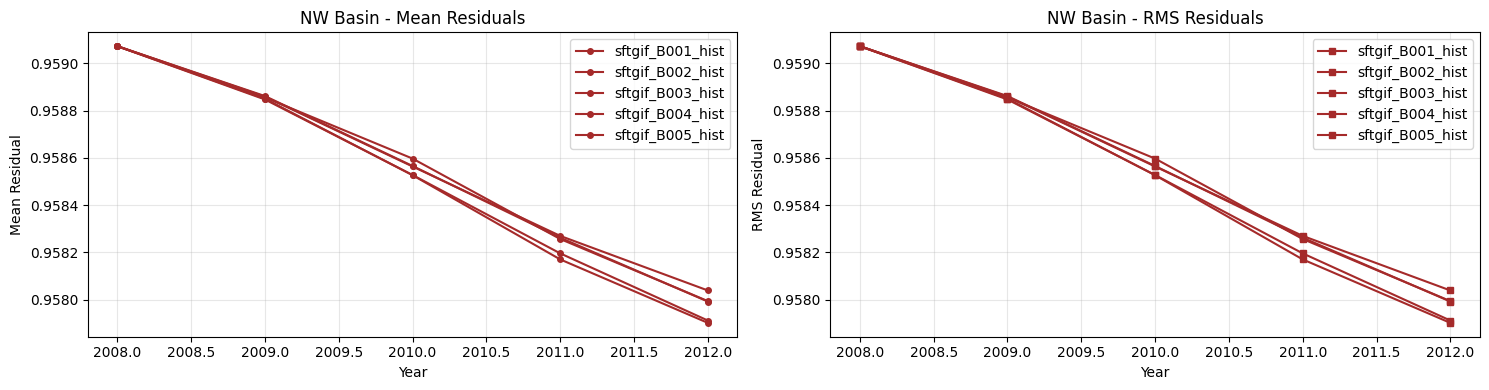

In [8]:
def create_ensemble_comparison_plots(ensemble_stats, basin_list, colors, output_dir):
    """
    Create comparison plots for all models in the ensemble
    """
    if not ensemble_stats:
        print("No ensemble statistics available for plotting")
        return
    
    # Create subplots for each basin
    n_basins = len(basin_list)
    fig, axes = plt.subplots(n_basins, 2, figsize=(15, 4*n_basins))
    
    if n_basins == 1:
        axes = axes.reshape(1, -1)
    
    for i, basin in enumerate(basin_list):
        ax_mean = axes[i, 0]
        ax_rms = axes[i, 1]
        
        # Plot mean residuals for all models
        for model_name, stats in ensemble_stats.items():
            if basin in stats:
                basin_data = stats[basin]
                years = list(basin_data.keys())
                mean_values = [basin_data[year]['mean'] for year in years]
                rms_values = [basin_data[year]['rms'] for year in years]
                
                ax_mean.plot(years, mean_values, label=model_name, 
                           color=colors.get(basin, 'black'), 
                           linestyle='--' if 'MODEL' in model_name else '-',
                           marker='o', markersize=4)
                
                ax_rms.plot(years, rms_values, label=model_name,
                          color=colors.get(basin, 'black'),
                          linestyle='--' if 'MODEL' in model_name else '-',
                          marker='s', markersize=4)
        
        ax_mean.set_title(f'{basin} Basin - Mean Residuals')
        ax_mean.set_xlabel('Year')
        ax_mean.set_ylabel('Mean Residual')
        ax_mean.legend()
        ax_mean.grid(True, alpha=0.3)
        
        ax_rms.set_title(f'{basin} Basin - RMS Residuals')
        ax_rms.set_xlabel('Year')
        ax_rms.set_ylabel('RMS Residual')
        ax_rms.legend()
        ax_rms.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/ensemble_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create ensemble comparison plots
create_ensemble_comparison_plots(ensemble_stats, basin_list, colors, output_dir)

In [9]:
def calculate_ensemble_statistics(ensemble_stats, basin_list):
    """
    Calculate ensemble mean, std, min, max for each basin and year
    """
    ensemble_summary = {}
    
    for basin in basin_list:
        ensemble_summary[basin] = {}
        
        # Get all years from first model
        first_model = list(ensemble_stats.keys())[0]
        if basin in ensemble_stats[first_model]:
            years = list(ensemble_stats[first_model][basin].keys())
            
            for year in years:
                mean_values = []
                rms_values = []
                
                for model_name, stats in ensemble_stats.items():
                    if basin in stats and year in stats[basin]:
                        mean_values.append(stats[basin][year]['mean'])
                        rms_values.append(stats[basin][year]['rms'])
                
                if mean_values and rms_values:
                    ensemble_summary[basin][year] = {
                        'mean': {
                            'ensemble_mean': np.mean(mean_values),
                            'ensemble_std': np.std(mean_values),
                            'ensemble_min': np.min(mean_values),
                            'ensemble_max': np.max(mean_values),
                            'n_models': len(mean_values)
                        },
                        'rms': {
                            'ensemble_mean': np.mean(rms_values),
                            'ensemble_std': np.std(rms_values),
                            'ensemble_min': np.min(rms_values),
                            'ensemble_max': np.max(rms_values),
                            'n_models': len(rms_values)
                        }
                    }
    
    return ensemble_summary

# Calculate ensemble statistics
ensemble_summary = calculate_ensemble_statistics(ensemble_stats, basin_list)

# Save ensemble summary
with open(f'{output_dir}/ensemble_summary.json', 'w') as f:
    json.dump(ensemble_summary, f, indent=2, default=str)

print("Ensemble Summary:")
for basin in basin_list:
    print(f"\n{basin} Basin:")
    if basin in ensemble_summary:
        for year in sorted(ensemble_summary[basin].keys()):
            year_data = ensemble_summary[basin][year]
            print(f"  {year}: Mean={year_data['mean']['ensemble_mean']:.4f}±{year_data['mean']['ensemble_std']:.4f}, "
                  f"RMS={year_data['rms']['ensemble_mean']:.4f}±{year_data['rms']['ensemble_std']:.4f} "
                  f"({year_data['mean']['n_models']} models)")

Ensemble Summary:

NW Basin:
  2008: Mean=0.9591±0.0000, RMS=0.9591±0.0000 (5 models)
  2009: Mean=0.9589±0.0000, RMS=0.9589±0.0000 (5 models)
  2010: Mean=0.9586±0.0000, RMS=0.9586±0.0000 (5 models)
  2011: Mean=0.9582±0.0000, RMS=0.9582±0.0000 (5 models)
  2012: Mean=0.9580±0.0001, RMS=0.9580±0.0001 (5 models)


# Final Memory Cleanup

In [10]:
# Final cleanup
if 'gsfc' in locals():
    del gsfc
if 'basins' in locals():
    del basins
if 'ensemble_results' in locals():
    del ensemble_results
if 'ensemble_stats' in locals():
    del ensemble_stats

clear_memory()
print(f"\nProcessing complete! Check {output_dir} for results.")
print(f"Final memory usage: {get_memory_usage():.1f} MB")

Memory after cleanup: 651.0 MB

Processing complete! Check /Users/aditya_pachpande/Documents/GitHub/CmCt/output/ensemble_results/ for results.
Final memory usage: 651.0 MB
